# Plus-Minus QNN — Blind Quantum Computing (BQC)

Este notebook demonstra o treinamento de um modelo de Rede Neural Quântica (QNN) integrado a uma simulação de rede quântica. O objetivo é classificar o dataset Plus-Minus utilizando uma abordagem de *Blind Quantum Computing* (BQC).

**O fluxo principal consiste em:**
1. Simular uma topologia de rede quântica em grade usando a biblioteca `quantumnet`.
2. Preparar o dataset Plus-Minus reduzindo sua dimensionalidade para adaptar ao número de qubits.
3. Criar uma QNN usando `qiskit-machine-learning` conectada ao PyTorch (`TorchConnector`).
4. Treinar o modelo com a injeção de ruído dinâmico, onde a taxa de erro do simulador é ajustada a cada época com base na fidelidade da rota da rede quântica.

In [139]:
!pip install aiohttp fsspec h5py


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [140]:
import sys
print(sys.executable)

!{sys.executable} -m pip install pennylane

C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:

!pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib numpy
!pip install pennylane pennylane-datasets


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


ERROR: Could not find a version that satisfies the requirement pennylane-datasets (from versions: none)
ERROR: No matching distribution found for pennylane-datasets

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [142]:
# Imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.quantum_info import SparsePauliOp

# Simulador e ruído
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Dataset e métricas
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Rede BQC
from quantumnet.components import Controller, Logger, Network

# PennyLane dataset
import pennylane as qml

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Controle de Aleatoriedade e Parâmetros Base

Garantimos a reprodutibilidade dos resultados fixando as *seeds* em todas as bibliotecas utilizadas (Python, NumPy, PyTorch e Qiskit). Também definimos o número de execuções (`SHOTS = 128`) para os circuitos quânticos e estabelecemos o protocolo de roteamento BFK_BQC que será utilizado na rede quântica.

In [ ]:

SEED = 512
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

try:
    from qiskit_algorithms.utils import algorithm_globals
    algorithm_globals.random_seed = SEED
except:
    pass

SHOTS = 128
protocolo = "BFK_BQC"


# Configuração da Rede Quântica

Aqui inicializamos o ambiente de simulação da rede (`quantumnet`). 
* Criamos uma topologia em grade de 10x10.
* Definimos um cliente (nó 6) e um servidor (nó 0).
* A função `enviar_circuito_por_epoca` é responsável por encapsular o circuito atual e enviá-lo como uma requisição através da rede, agendando *timeslots* e rotas.

2026-01-14 07:37:33,549: Host 0 inicializado com 0 qubits.
2026-01-14 07:37:33,550: Host 1 inicializado com 0 qubits.
2026-01-14 07:37:33,551: Host 2 inicializado com 0 qubits.
2026-01-14 07:37:33,552: Host 3 inicializado com 0 qubits.
2026-01-14 07:37:33,552: Host 4 inicializado com 0 qubits.
2026-01-14 07:37:33,553: Host 5 inicializado com 0 qubits.
2026-01-14 07:37:33,553: Host 6 inicializado com 0 qubits.
2026-01-14 07:37:33,554: Host 7 inicializado com 0 qubits.
2026-01-14 07:37:33,556: Host 8 inicializado com 0 qubits.
2026-01-14 07:37:33,557: Host 9 inicializado com 0 qubits.
2026-01-14 07:37:33,558: Host 10 é o servidor, não receberá qubits.
2026-01-14 07:37:33,559: Host 11 inicializado com 0 qubits.
2026-01-14 07:37:33,559: Host 12 inicializado com 0 qubits.
2026-01-14 07:37:33,560: Host 13 inicializado com 0 qubits.
2026-01-14 07:37:33,560: Host 14 inicializado com 0 qubits.
2026-01-14 07:37:33,562: Host 15 inicializado com 0 qubits.
2026-01-14 07:37:33,562: Host 16 inicializ

Hosts inicializados
Canais inicializados


2026-01-14 07:37:33,682: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB65CB99D0> adicionado ao canal.
2026-01-14 07:37:33,683: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB65C2B290> adicionado ao canal.
2026-01-14 07:37:33,684: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB65CE8150> adicionado ao canal.
2026-01-14 07:37:33,684: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB65CA0050> adicionado ao canal.
2026-01-14 07:37:33,685: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB65CEB810> adicionado ao canal.
2026-01-14 07:37:33,686: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB65CE8390> adicionado ao canal.
2026-01-14 07:37:33,687: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB65C62910> adicionado ao canal.
2026-01-14 07:37:33,688: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB65C39290> adicionado ao canal.
2026-01-14 07:37:33,690: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB65CE9010> adicionado ao

Pares EPRs adicionados
Topologia configurada com sucesso para slices!
Final Slice Paths for 1 slices: [[6, 5, 4, 3, 2, 1, 0]]


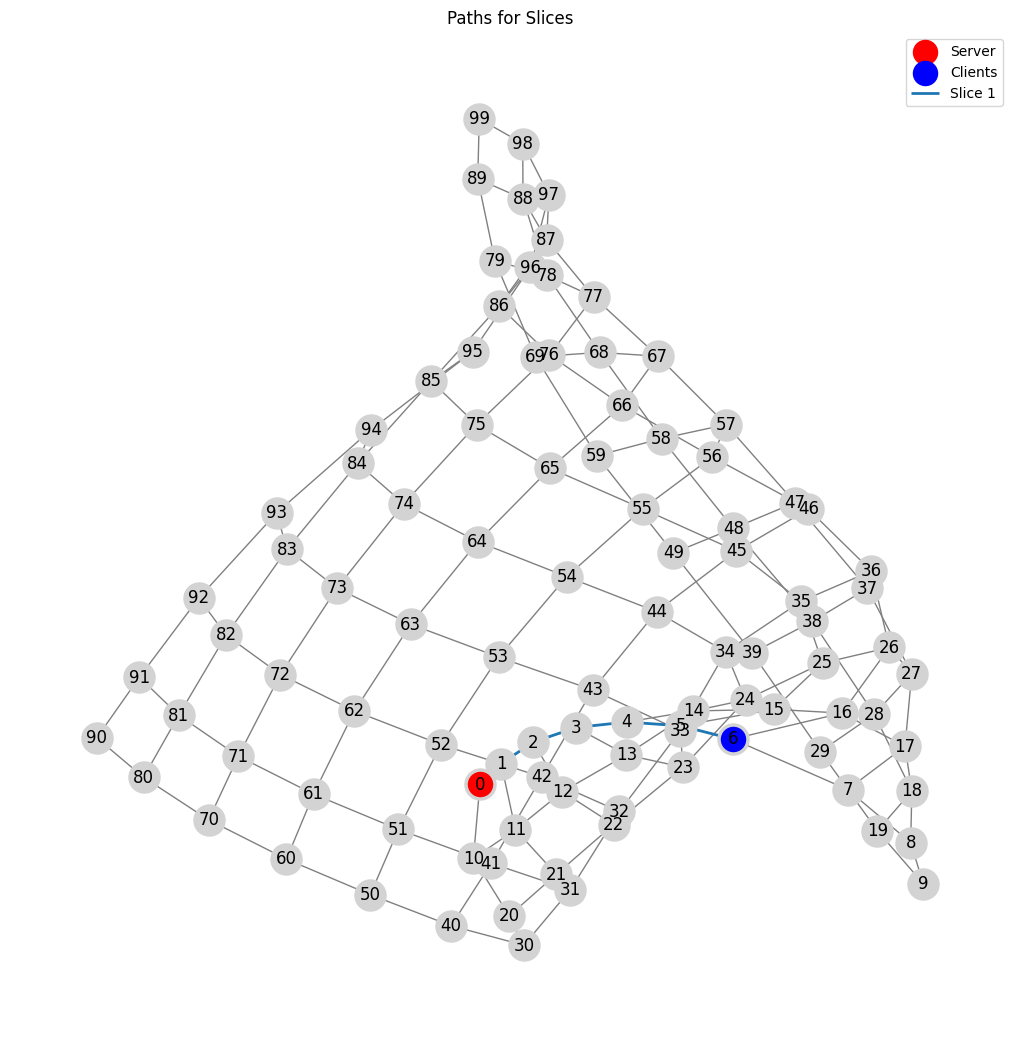

2026-01-14 07:37:34,408: Simulação de slices concluída para 1 clientes e servidor 0.
2026-01-14 07:37:34,409: Slice slice_1 configurado com cliente 6, servidor 0, protocolo BFK_BQC e caminho [6, 5, 4, 3, 2, 1, 0].


In [ ]:
def enviar_circuito_por_epoca(circuito, epoch, num_qubits, circuit_depth, rede=None, controlador=None, slice_paths_list=None):
    print(f"[Epoch {epoch+1}] Enviando circuito para a rede...")

    slice_path = slice_paths_list[0] if slice_paths_list else []

    request = {
        "alice_id": 6,
        "bob_id": 0,
        "num_qubits": num_qubits,
        "quantum_circuit": circuito,
        "circuit_depth": circuit_depth,
        "protocol": protocolo,
        "slice_path": slice_path,
        "scenario": 2
    }

    rede.requests_queue.append(request)

    scheduled_timeslots = controlador.schedule_requests(
        requests=rede.requests_queue,
        slice_paths=controlador.slices,
        protocols=protocolo
    )

    rede.execute_scheduled_requests(scheduled_timeslots, slice_paths=controlador.slices)
    print(f"[Epoch {epoch+1}] Envio concluído.")

rede = Network()
controlador = Controller(rede)

clients = [6]
server = 0
protocols = [protocolo]

rede.set_topology_for_slices(
    graph_type='grade',
    dimensions=(10, 10),
    clients=clients,
    server=server
)

slice_paths_list = rede.run_slice_simulation(clients=clients, server=server)

Logger.activate(Logger)

controlador.initialize_slices(
    network=rede,
    clients=clients,
    server=server,
    protocols=protocols,
    slice_paths_list=slice_paths_list
)


# Processamento do Dataset Plus-Minus

Nesta etapa, carregamos os dados de imagens do dataset `plus-minus` através do PennyLane. Como imagens cruas exigiriam muitos qubits, aplicamos o seguinte pipeline clássico:
1. **Achatamento (Flatten):** Transformamos as matrizes 2D em vetores 1D.
2. **PCA:** Reduzimos a dimensionalidade para apenas **2 componentes principais**. Isso define que usaremos apenas 2 qubits no nosso circuito.
3. **Normalização:** Escalamos os valores entre 0 e 1 usando `MinMaxScaler`.
4. **Conversão de Classes:** Transformamos os rótulos originais para o formato binário 0/1.
5. **Tensores PyTorch:** Convertamos os arrays para tensores, preparando-os para o `DataLoader` e para o `TorchConnector`.

In [ ]:

try:
    [ds] = qml.data.load("plus-minus", force=True)
except:
    [ds] = qml.data.load("plus-minus", force=True, folder_path="./data")


[ds] = qml.data.load("plus-minus", force=True, folder_path="./data")


X = ds.img_train
y = ds.labels_train
X_test = ds.img_test
y_test = ds.labels_test


X = X.reshape((X.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

pca = PCA(n_components=2, random_state=SEED)
X = pca.fit_transform(X)
X_test = pca.transform(X_test)

scaler = MinMaxScaler((0, 1))
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

def to_01(arr):
    arr = np.array(arr).astype(np.float32)
    return ((arr > 0).astype(np.float32)).reshape(-1, 1)

y_train = to_01(y_train)
y_val = to_01(y_val)
y_test = to_01(y_test)



# Integração Qiskit + PyTorch (TorchConnector)

Instanciamos o `EstimatorQNN` usando o circuito criado e o conectamos ao PyTorch através do `TorchConnector`. Inicializamos os pesos aleatoriamente e definimos a função de perda (`CrossEntropyLoss`) e o otimizador (`Adam`).

In [ ]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


y_train_tensor = torch.tensor(y_train, dtype=torch.long).squeeze()
y_val_tensor   = torch.tensor(y_val, dtype=torch.long).squeeze()
y_test_tensor  = torch.tensor(y_test, dtype=torch.long).squeeze()

# Arquitetura do Circuito Quântico (Ansatz e Feature Map)

Construímos o circuito quântico base para a QNN:
* **Feature Map:** Usamos um `PauliFeatureMap` com portas `['X', 'Z', 'ZZ']` e 2 repetições para codificar os dados clássicos em estados quânticos.
* **Ansatz:** Adicionamos um `RealAmplitudes` parametrizado que servirá como os "pesos" da nossa rede neural quântica.
* **Observáveis:** Definimos a medição no eixo Z para gerar a saída que será interpretada pelo PyTorch.

In [ ]:

num_qubits = X_train.shape[1]   
num_classes = len(np.unique(y)) 

print(num_qubits, num_classes)

feature_map = PauliFeatureMap(
    num_qubits,
    paulis=['X', 'Z', 'ZZ'],
    reps=2
)


ansatz = RealAmplitudes(
    num_qubits,
    reps=1
)

qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

observables = [
    SparsePauliOp.from_list([
        ("I" * i + "Z" + "I" * (num_qubits - i - 1), 1.0)
    ])
    for i in range(num_qubits)
]


2 4


# Gerenciamento Dinâmico de Ruído

A função `gerenciar_ruido` é o elo principal entre a rede neural e a simulação da rede quântica. Ela consulta a fidelidade média da camada de aplicação da rede (`rede.application_layer`) e mapeia esse valor para uma probabilidade de erro despolarizante (`noise_p`). Com isso, construímos um `AerSimulator` que imita as condições reais e dinâmicas da rede quântica durante o treinamento.

In [ ]:

def gerenciar_ruido(rede=None, num_qubits=4):
    """Versão adaptada do gerenciador de ruído para IRIS com BackendSampler"""
    
    noise_p = 0.01 
    
    if rede is None:
        print("[gerenciar_ruido] Rede não disponível — mantendo ruído padrão.")
        simulator = AerSimulator(shots=SHOTS)
        return simulator, noise_p
    
    try:
        fidelity = 0.8  
        
        if hasattr(rede, 'application_layer') and rede.application_layer:
            try:
                if hasattr(rede.application_layer, 'route_fidelities') and rede.application_layer.route_fidelities:
                    fidelities = rede.application_layer.route_fidelities
                    fidelity = sum(fidelities) / len(fidelities)
                    fidelity = max(0.6, min(0.99, fidelity))
                else:
                    fidelity = rede.application_layer.avg_fidelity_on_applicationlayer()
            except:
                fidelity = 0.8
        
        if fidelity >= 0.95:
            noise_p = 0.001 
        elif fidelity >= 0.90:
            noise_p = 0.004
        elif fidelity >= 0.85:
            noise_p = 0.005
        elif fidelity >= 0.80:
            noise_p = 0.008
        elif fidelity >= 0.75:
            noise_p = 0.01
        elif fidelity >= 0.70:
            noise_p = 0.02
        elif fidelity >= 0.65:
            noise_p = 0.04
        elif fidelity >= 0.60:
            noise_p = 0.08
        else:
            noise_p = 0.25 
        
        print(f" MAPEAMENTO: F={fidelity:.3f} → noise_p={noise_p:.3f}")
        
        dynamic_noise = NoiseModel()
        
        error_single = depolarizing_error(noise_p, 1)
        dynamic_noise.add_all_qubit_quantum_error(error_single, 
            ['id', 'x', 'y', 'z', 'h', 's', 'sdg', 't', 'tdg', 'rx', 'ry', 'rz'])
        
        error_double = depolarizing_error(min(0.5, noise_p * 3), 2)
        dynamic_noise.add_all_qubit_quantum_error(error_double, ['cx', 'cz', 'swap'])
        
        simulator = AerSimulator(
            noise_model=dynamic_noise, 
            shots=SHOTS,
            method='density_matrix',
            seed_simulator=SEED
        )
        
        return simulator, noise_p
        
    except Exception as e:
        print(f"ERRO em gerenciar_ruido: {e}")
        simulator = AerSimulator(shots=SHOTS)
        return simulator, 0.01 


  

In [ ]:

simulator = AerSimulator(shots=SHOTS)
estimator = Estimator(options={"backend": simulator})

qnn = EstimatorQNN(
    circuit=qc,
    estimator=estimator,
    observables=observables,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters
)

initial_weights = 0.01 * np.random.randn(qnn.num_weights)

model = TorchConnector(qnn, initial_weights=initial_weights)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.05)


C:\Users\Dreysv\AppData\Local\Temp\ipykernel_1156\1928820337.py:3: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator(options={"backend": simulator})
C:\Users\Dreysv\AppData\Local\Temp\ipykernel_1156\1928820337.py:6: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = EstimatorQNN(


# # Loop de Treinamento Híbrido

Durante cada época de treinamento, realizamos as seguintes operações integradas:
1. **Atualização de Ruído:** O simulador é recriado com o ruído correspondente à fidelidade atual da rede.
2. **Backpropagation:** O PyTorch calcula as predições, a perda, e otimiza os parâmetros do circuito (pesos do ansatz).
3. **Feedback de Fidelidade:** A acurácia obtida no conjunto de teste influencia uma "nova fidelidade alvo" da rede, que é atualizada usando uma média móvel (fator `FID_ALPHA`).
4. **Simulação de Envio:** O circuito recém-treinado é empacotado e enviado pela rede quântica usando a função `enviar_circuito_por_epoca`.

In [ ]:

num_epochs = 20
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

train_losses = []
train_accuracies = []
test_accuracies = []

FID_ALPHA = 0.5

for epoch in range(num_epochs):
    print(f"\n=== ÉPOCA {epoch+1}/{num_epochs} ===")

    simulator_updated, noise_used = gerenciar_ruido(rede)
    estimator_updated = Estimator(options={"backend": simulator_updated})
    model.neural_network.estimator = estimator_updated


    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)            
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()


        total_loss += loss.item()
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

    train_acc = correct / total

    model.eval()
    with torch.no_grad():
        out_test = model(X_test_tensor)
        _, pred_test = torch.max(out_test, 1)
        test_acc = (pred_test == y_test_tensor).sum().item() / len(y_test_tensor)

    f_ant = rede.application_layer.avg_fidelity_on_applicationlayer()
    f_target = 0.6 + test_acc * 0.38
    nova_fidelidade = FID_ALPHA * f_ant + (1 - FID_ALPHA) * f_target

    rede.application_layer.route_fidelities = [
        nova_fidelidade for _ in rede.application_layer.route_fidelities
    ]

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Loss: {train_losses[-1]:.4f}")
    print(f"Acurácia treino: {train_acc:.4f} | teste: {test_acc:.4f}")
    print(f"Fidelidade: {nova_fidelidade:.4f}")

    enviar_circuito_por_epoca(
        circuito=qc,
        epoch=epoch,
        num_qubits=num_qubits,
        circuit_depth=qc.depth(),
        rede=rede,
        controlador=controlador,
        slice_paths_list=slice_paths_list
    )

2026-01-14 07:37:39,385: Nenhuma fidelidade foi registrada na camada de aplicação.



=== ÉPOCA 1/20 ===
 MAPEAMENTO: F=0.000 → noise_p=0.250


C:\Users\Dreysv\AppData\Local\Temp\ipykernel_1156\2756645746.py:18: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator_updated = Estimator(options={"backend": simulator_updated})
2026-01-14 07:38:08,879: Nenhuma fidelidade foi registrada na camada de aplicação.
2026-01-14 07:38:08,880: Reiniciando a rede antes de processar o timeslot 1.
2026-01-14 07:38:08,886: Rede reiniciada com sucesso.
2026-01-14 07:38:08,887: Rede reiniciada. Timeslot atual: 1.
2026-01-14 07:38:08,887: Timeslot avançado para 1.
2026-01-14 07:38:08,887: Executando requisições do timeslot 1.
2026-01-14 07:38:08,887: Executando requisição: Alice 6 -> Bob 0, Protocolo: BFK_BQC
2026-01-14 07:38:08,887: Slice 

Loss: 0.5983
Acurácia treino: 0.7575 | teste: 0.9250
Fidelidade: 0.4758
[Epoch 1] Enviando circuito para a rede...
Pares EPRs adicionados
Hosts inicializados
Tempo de Operação: None
[Epoch 1] Envio concluído.

=== ÉPOCA 2/20 ===
 MAPEAMENTO: F=0.849 → noise_p=0.008


2026-01-14 07:38:37,284: A média das fidelidades das rotas é: 0.8494
2026-01-14 07:38:37,285: Reiniciando a rede antes de processar o timeslot 1.
2026-01-14 07:38:37,291: Rede reiniciada com sucesso.
2026-01-14 07:38:37,292: Rede reiniciada. Timeslot atual: 1.
2026-01-14 07:38:37,292: Executando requisições do timeslot 1.
2026-01-14 07:38:37,293: Executando requisição: Alice 6 -> Bob 0, Protocolo: BFK_BQC
2026-01-14 07:38:37,293: Slice Path fornecido: [6, 5, 4, 3, 2, 1, 0]
2026-01-14 07:38:37,294: Rota extraída para execução: [6, 5, 4, 3, 2, 1, 0]
2026-01-14 07:38:37,295: Protocolo configurado para 2 rodadas.
2026-01-14 07:38:37,297: Timeslot 7. Iniciando protocolo BFK com 2 qubits, 2 rodadas, e cenário 2.
2026-01-14 07:38:37,298: Memória do cliente 6 (Alice) limpa com sucesso.
2026-01-14 07:38:37,299: Memória do servidor 0 (Bob) limpa com sucesso.
2026-01-14 07:38:37,302: Timeslot 8.
2026-01-14 07:38:37,303: Qubit 512 preparado pelo cliente 6.
2026-01-14 07:38:37,304: Qubit 138 prepar

...

Pares EPRs adicionados
Hosts inicializados
Tempo de Operação: None


2026-01-14 07:48:02,651: Qubit 580 preparado pelo cliente 6.
2026-01-14 07:48:02,651: Qubit 317 preparado pelo cliente 6.
2026-01-14 07:48:02,651: Usando rota específica para o transporte: [6, 5, 4, 3, 2, 1, 0]
2026-01-14 07:48:02,652: Limpando pares EPRs residuais na rota: [6, 5, 4, 3, 2, 1, 0]
2026-01-14 07:48:02,652: Pares EPRs limpos no segmento 6 -> 5.
2026-01-14 07:48:02,652: Pares EPRs limpos no segmento 5 -> 4.
2026-01-14 07:48:02,653: Pares EPRs limpos no segmento 4 -> 3.
2026-01-14 07:48:02,653: Pares EPRs limpos no segmento 3 -> 2.
2026-01-14 07:48:02,653: Pares EPRs limpos no segmento 2 -> 1.
2026-01-14 07:48:02,654: Pares EPRs limpos no segmento 1 -> 0.
2026-01-14 07:48:02,654: Qubit 103871 adicionado à memória do Host 6.
2026-01-14 07:48:02,655: Qubit 103871 criado com fidelidade inicial 0.995806836437513 e adicionado à memória do Host 6.
2026-01-14 07:48:02,655: Qubit 103872 adicionado à memória do Host 6.
2026-01-14 07:48:02,655: Qubit 103872 criado com fidelidade inici

Pares EPRs adicionados
Hosts inicializados
Tempo de Operação: None


2026-01-14 07:48:03,118: Pares EPRs limpos no segmento 1 -> 0.
2026-01-14 07:48:03,118: Qubit 104368 adicionado à memória do Host 6.
2026-01-14 07:48:03,119: Qubit 104368 criado com fidelidade inicial 0.9587199709359848 e adicionado à memória do Host 6.
2026-01-14 07:48:03,119: Qubit 104369 adicionado à memória do Host 6.
2026-01-14 07:48:03,120: Qubit 104369 criado com fidelidade inicial 0.9640555499189077 e adicionado à memória do Host 6.
2026-01-14 07:48:03,120: Timeslot 1048 Usando a rota fornecida: [6, 5, 4, 3, 2, 1, 0]
2026-01-14 07:48:03,120: Timeslot 1048 Iniciando criação de pares EPRs para o Cenário 2.
2026-01-14 07:48:03,121: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB64CB7350> adicionado ao canal (6, 5).
2026-01-14 07:48:03,121: Par EPR <quantumnet.objects.epr.Epr object at 0x000002BB66E58F10> adicionado ao canal (6, 5).
2026-01-14 07:48:03,121: Timeslot 1048 Pares EPRs criados para o enlace 6 -> 5.
2026-01-14 07:48:03,122: Par EPR <quantumnet.objects.epr.Epr o

[Epoch 20] Envio concluído.


# Avaliação do Modelo e Métricas da Rede Quântica

Após o fim do treinamento, avaliamos a capacidade de generalização do modelo no conjunto de teste. Aqui nós geramos:
* Relatórios de classificação (Acurácia, Precisão, Recall, F1-Score).
* A Matriz de Confusão formatada.
* Gráficos da evolução de Perda e Acurácia ao longo das épocas.
* Gráfico visual comparando as classes reais vs. previstas.
* **Métricas da Rede Quântica:** Quantidade total de pares EPRs consumidos durante a simulação e a fidelidade final da rota estabelecida.

In [ ]:
def mostrar_matriz_confusao(y_true, y_pred, classes=None, title='Matriz de Confusão'):
    """Mostra matriz de confusão formatada"""
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n{title}")
    print("=" * 40)
    
    if classes is None:
        classes = [f'Classe {i}' for i in range(len(cm))]
    
    # Cabeçalho
    header = "         " + " ".join(f"{cls:>8}" for cls in classes)
    print(header)
    print(" " * 9 + "-" * (len(classes) * 9))
    
    for i, row in enumerate(cm):
        row_str = f"{classes[i]:<8} |"
        for val in row:
            row_str += f" {val:>7}"
        print(row_str)
    
    return cm

In [151]:
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    _, y_pred = torch.max(y_pred_tensor, 1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nMÉTRICAS FINAIS")
print(f"Acurácia : {accuracy:.4f}")
print(f"Precisão : {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nRELATÓRIO:")
print(classification_report(y_test, y_pred, target_names=["minus", "plus"]))



MÉTRICAS FINAIS
Acurácia : 0.9250
Precisão : 0.9655
Recall   : 0.9333
F1-score : 0.9492

RELATÓRIO:
              precision    recall  f1-score   support

       minus       0.82      0.90      0.86        50
        plus       0.97      0.93      0.95       150

    accuracy                           0.93       200
   macro avg       0.89      0.92      0.90       200
weighted avg       0.93      0.93      0.93       200



In [ ]:
print("\n" + "="*60)
print("AVALIAÇÃO FINAL DO MODELO")
print("="*60)

model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    _, y_pred_labels = torch.max(y_pred_tensor.data, 1)
    y_pred = y_pred_labels.numpy()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nMÉTRICAS GLOBAIS:")
print(f"Acurácia  : {accuracy:.4f}")
print(f"Precisão  : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print(f"\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["minus", "plus"]
    )
)

print("\nMATRIZ DE CONFUSÃO:")
cm = mostrar_matriz_confusao(
    y_test,
    y_pred,
    classes=["minus", "plus"],
    title="Matriz de Confusão - PLUS-MINUS QNN"
)


AVALIAÇÃO FINAL DO MODELO

MÉTRICAS GLOBAIS:
Acurácia  : 0.9250
Precisão  : 0.9287
Recall    : 0.9250
F1-Score  : 0.9262

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

       minus       0.82      0.90      0.86        50
        plus       0.97      0.93      0.95       150

    accuracy                           0.93       200
   macro avg       0.89      0.92      0.90       200
weighted avg       0.93      0.93      0.93       200


MATRIZ DE CONFUSÃO:

Matriz de Confusão - PLUS-MINUS QNN
            minus     plus
         ------------------
minus    |      45       5
plus     |      10     140


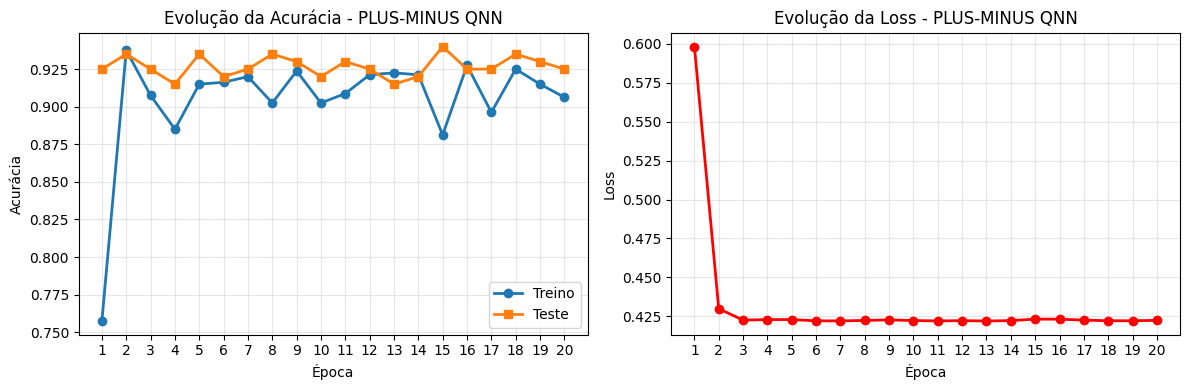

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs + 1), train_accuracies, 'o-', label='Treino', linewidth=2)
ax1.plot(range(1, num_epochs + 1), test_accuracies, 's-', label='Teste', linewidth=2)
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.set_title('Evolução da Acurácia - PLUS-MINUS QNN')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, num_epochs + 1))

ax2.plot(range(1, num_epochs + 1), train_losses, 'o-', color='red', linewidth=2)
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.set_title('Evolução da Loss - PLUS-MINUS QNN')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, num_epochs + 1))

plt.tight_layout()
plt.show()


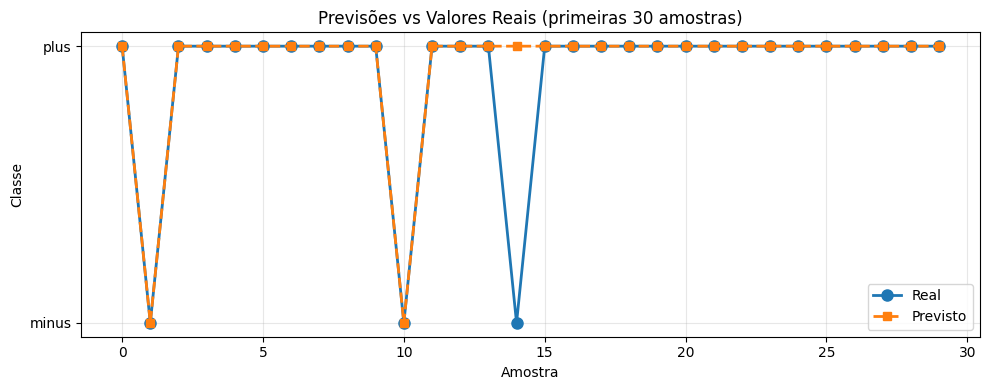

In [ ]:

plt.figure(figsize=(10, 4))
n_samples = min(30, len(y_test))

plt.plot(
    y_test[:n_samples],
    'o-',
    label='Real',
    markersize=8,
    linewidth=2
)

plt.plot(
    y_pred[:n_samples],
    's--',
    label='Previsto',
    markersize=6,
    linewidth=2
)

plt.xlabel('Amostra')
plt.ylabel('Classe')
plt.title(f'Previsões vs Valores Reais (primeiras {n_samples} amostras)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yticks([0, 1], ["minus", "plus"])
plt.tight_layout()
plt.show()

In [ ]:

eprs_usados = rede.get_total_useds_eprs()
print(f"EPRs usados na camada ApplicationLayer: {eprs_usados}")

fidelidade_media = rede.application_layer.avg_fidelity_on_applicationlayer()
print(f"Fidelidade média das rotas: {fidelidade_media:.4f}")

print("\nFidelidades por rota:")
rede.application_layer.print_route_fidelities()

2026-01-14 07:48:06,418: Eprs usados na camada LinkLayer: 0
2026-01-14 07:48:06,419: Eprs usados na camada NetworkLayer: 0
2026-01-14 07:48:06,420: Eprs usados na camada ApplicationLayer: 2520
2026-01-14 07:48:06,422: A média das fidelidades das rotas é: 0.9352


EPRs usados na camada ApplicationLayer: 2520
Fidelidade média das rotas: 0.9352

Fidelidades por rota:
Fidelidades das rotas utilizadas:
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.9432
0.